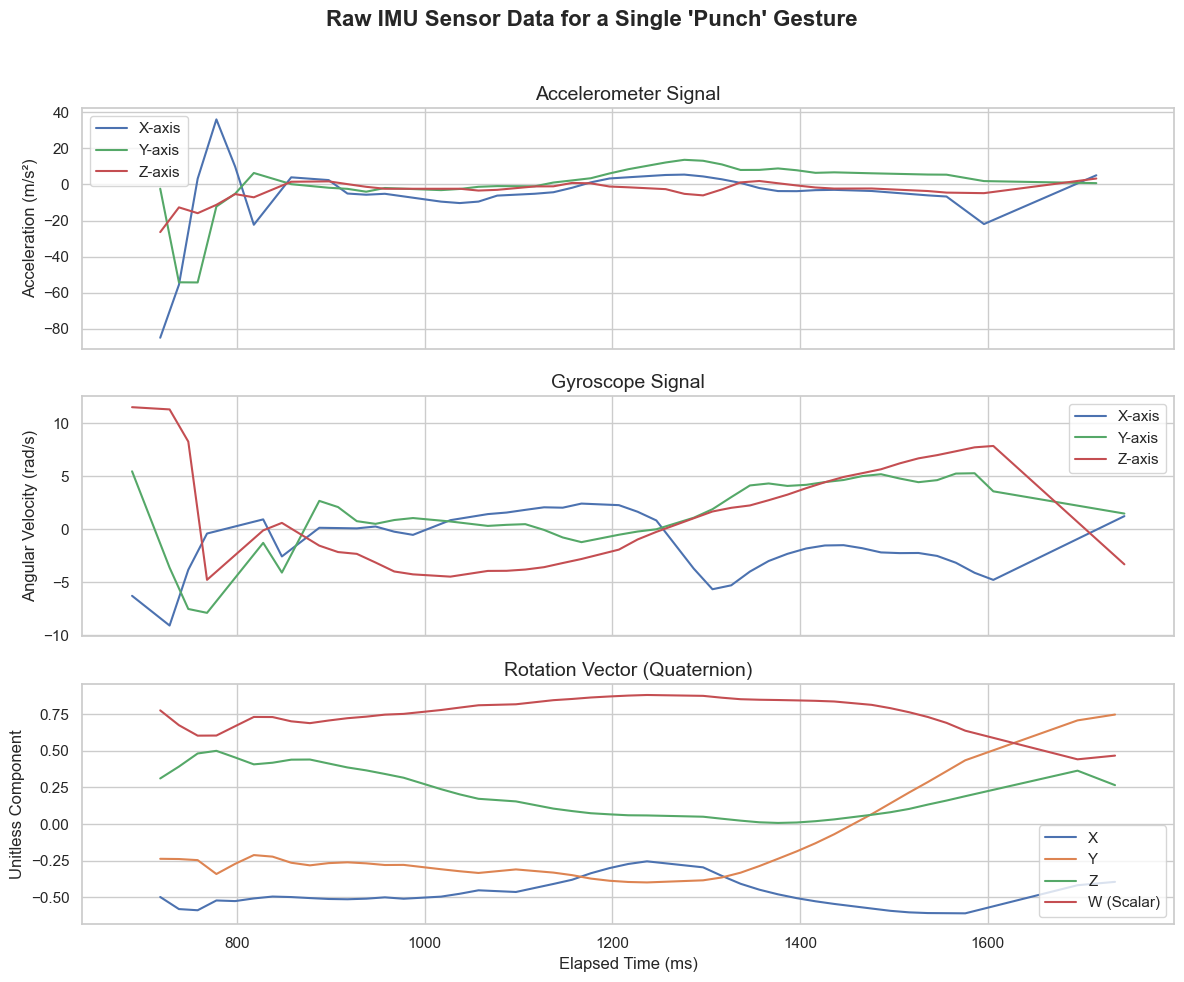

In [5]:
# Figure 1.1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration ---
file_path = Path("data/button_collected/punch_1760861137264_to_1760861138638.csv")

# --- Data Loading and Preprocessing ---

# Load the raw, unmerged data from the CSV
df = pd.read_csv(file_path)

# The raw timestamp is in nanoseconds. Convert it to a more readable
# "elapsed time in milliseconds" format for the x-axis.
start_time = df["timestamp"].min()
df["elapsed_ms"] = (df["timestamp"] - start_time) / 1_000_000

# The data is "sparse" - each row only contains data for one sensor.
# We filter the DataFrame into three separate ones for plotting.
accel_df = df[df["sensor"] == "linear_acceleration"].copy()
gyro_df = df[df["sensor"] == "gyroscope"].copy()
rot_df = df[df["sensor"] == "rotation_vector"].copy()

# --- Visualization ---
# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots stacked vertically.
# `sharex=True` links the x-axes, making comparison easy.
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True)

# Plot 1: Accelerometer Data
sns.lineplot(
    data=accel_df,
    x="elapsed_ms",
    y="accel_x",
    ax=axes[0],
    label="X-axis",
    color="b",
)
sns.lineplot(
    data=accel_df,
    x="elapsed_ms",
    y="accel_y",
    ax=axes[0],
    label="Y-axis",
    color="g",
)
sns.lineplot(
    data=accel_df,
    x="elapsed_ms",
    y="accel_z",
    ax=axes[0],
    label="Z-axis",
    color="r",
)
axes[0].set_title("Accelerometer Signal", fontsize=14)
axes[0].set_ylabel("Acceleration (m/s²)")
axes[0].legend()

# Plot 2: Gyroscope Data
sns.lineplot(
    data=gyro_df, x="elapsed_ms", y="gyro_x", ax=axes[1], label="X-axis", color="b"
)
sns.lineplot(
    data=gyro_df, x="elapsed_ms", y="gyro_y", ax=axes[1], label="Y-axis", color="g"
)
sns.lineplot(
    data=gyro_df, x="elapsed_ms", y="gyro_z", ax=axes[1], label="Z-axis", color="r"
)
axes[1].set_title("Gyroscope Signal", fontsize=14)
axes[1].set_ylabel("Angular Velocity (rad/s)")
axes[1].legend()

# Plot 3: Rotation Vector Data
sns.lineplot(data=rot_df, x="elapsed_ms", y="rot_x", ax=axes[2], label="X")
sns.lineplot(data=rot_df, x="elapsed_ms", y="rot_y", ax=axes[2], label="Y")
sns.lineplot(data=rot_df, x="elapsed_ms", y="rot_z", ax=axes[2], label="Z")
sns.lineplot(data=rot_df, x="elapsed_ms", y="rot_w", ax=axes[2], label="W (Scalar)")
axes[2].set_title("Rotation Vector (Quaternion)", fontsize=14)
axes[2].set_ylabel("Unitless Component")
axes[2].set_xlabel("Elapsed Time (ms)", fontsize=12)
axes[2].legend()

# Add a main title for the entire figure
fig.suptitle(
    "Raw IMU Sensor Data for a Single 'Punch' Gesture",
    fontsize=16,
    fontweight="bold",
)

# Adjust layout to prevent titles from overlapping
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Display the final plot
plt.show()

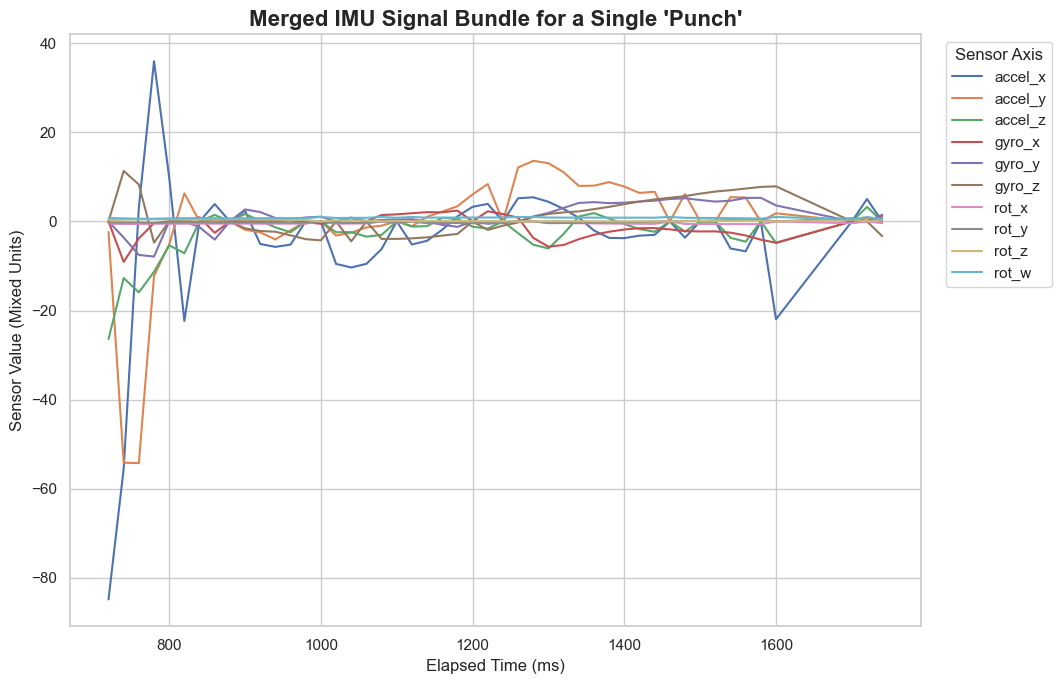

In [8]:
# Figure 1.2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# --- Configuration ---
# TODO: Update this path to the location of your MERGED data file.
file_path = Path(
    "/Users/cvk/Downloads/CODELocalProjects/v3pls/data/merged_training/punch_1760861137264_to_1760861138638.csv"
)
MOTION_THRESHOLD = 5.0  # Threshold to trim pre-motion silence

# --- Data Loading and Preprocessing ---
try:
    df = pd.read_csv(file_path)

    if "timestamp" in df.columns:
        df["elapsed_ms"] = (df["timestamp"] - df["timestamp"].min()) / 1_000_000
        x_axis_label = "Elapsed Time (ms)"

        # --- Automatic Motion Detection to trim the idle start ---
        accel_magnitude = np.sqrt(
            df["accel_x"] ** 2 + df["accel_y"] ** 2 + df["accel_z"] ** 2
        )
        motion_start_index = (accel_magnitude > MOTION_THRESHOLD).idxmax()
        motion_start_time = df.loc[motion_start_index, "elapsed_ms"]
        df_action = df[df["elapsed_ms"] >= motion_start_time].copy()
    else:
        df_action = df
        x_axis_label = "Sample Index"
        print("Warning: 'timestamp' column not found.")

    # --- Visualization ---
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    # Columns to plot
    columns_to_plot = [
        "accel_x",
        "accel_y",
        "accel_z",
        "gyro_x",
        "gyro_y",
        "gyro_z",
        "rot_x",
        "rot_y",
        "rot_z",
        "rot_w",
    ]

    # Plot all sensor columns on the same axis
    for col in columns_to_plot:
        sns.lineplot(data=df_action, x="elapsed_ms", y=col, label=col)

    plt.title(
        "Merged IMU Signal Bundle for a Single 'Punch'", fontsize=16, fontweight="bold"
    )
    plt.xlabel(x_axis_label, fontsize=12)
    plt.ylabel("Sensor Value (Mixed Units)", fontsize=12)
    plt.legend(title="Sensor Axis", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make space for legend
    plt.show()

except FileNotFoundError:
    print(f"--- ERROR: Data file not found at '{file_path}' ---")

*** 
Section 2

In [13]:
import graphviz

# --- Create the Flowchart ---
try:
    # Initialize a new directed graph
    dot = graphviz.Digraph(comment="Data Loading Pipeline")
    dot.attr(rankdir="LR", splines="ortho")  # Left-to-Right layout, straight lines

    # Define the style for the nodes
    node_style = {
        "shape": "box",
        "style": "rounded,filled",
        "fillcolor": "#e8f4f8",
        "fontname": "Helvetica",
        "fontsize": "12",
    }

    # Define the nodes (the steps in our pipeline)
    dot.node("A", "Scan Directories\n(e.g., .../punch/)", **node_style)
    dot.node(
        "B",
        "For each .csv file:\n- Load with pandas\n- Validate (check length > 10)",
        **node_style,
    )
    dot.node("C", "Assemble into Final\nData Structures", **node_style)

    # Define the output nodes
    output_style = node_style.copy()
    output_style["fillcolor"] = "#d4edda"
    dot.node("X", "X\n(List of NumPy Arrays)", **output_style)
    dot.node("y", "y\n(NumPy Label Vector)", **output_style)

    # Define the connections (edges) between the steps
    dot.edge("A", "B", label=" file paths ")
    dot.edge("B", "C", label=" validated data ")
    dot.edge("C", "X")
    dot.edge("C", "y")

    # --- Render and Save the Flowchart ---
    # This saves the flowchart as a PNG file in your project directory
    output_filename = "data_loading_flowchart"
    dot.render(output_filename, format="png", cleanup=True)

    print(f"✅ Flowchart successfully generated and saved as '{output_filename}.png'")
    print("You can now embed this image in your markdown cell.")

except ImportError:
    print("--- ERROR ---")
    print("The 'graphviz' library is not installed.")
    print("Please install it by running: pip install graphviz")
except graphviz.backend.ExecutableNotFound:
    print("--- ERROR ---")
    print(
        "Graphviz executable not found. This library requires a system-level installation."
    )
    print("  - On macOS, run: brew install graphviz")
    print("  - On Debian/Ubuntu, run: sudo apt-get install graphviz")

✅ Flowchart successfully generated and saved as 'data_loading_flowchart.png'
You can now embed this image in your markdown cell.


![Data Loading Flowchart](data_loading_flowchart.png)

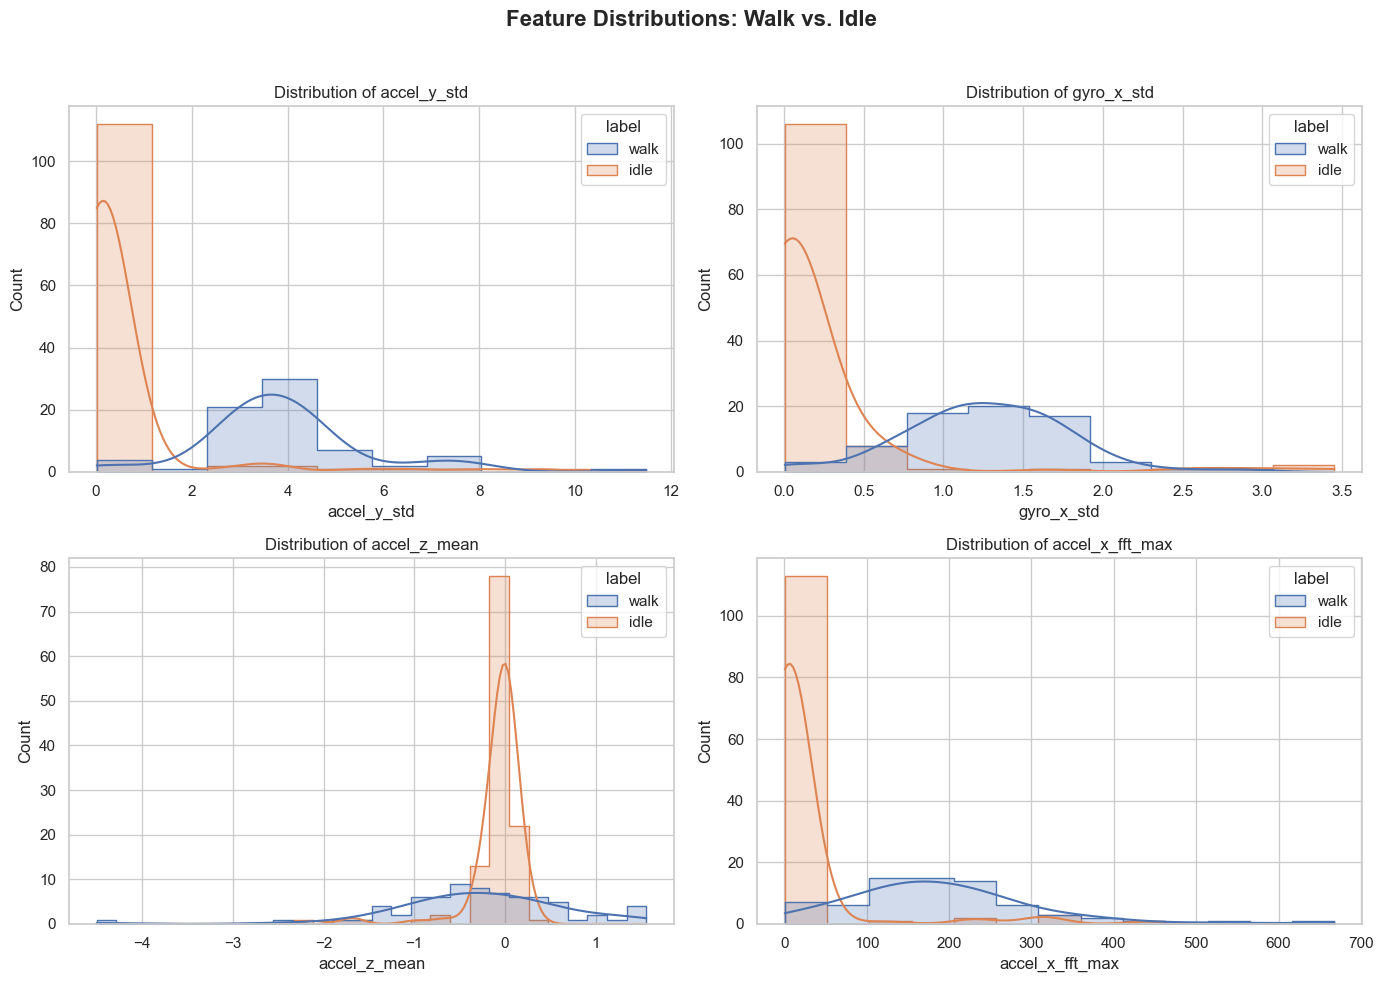

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- I selected a few features I expected to be highly discriminative ---
features_to_plot = [
    "accel_y_std",  # Expect higher for 'walk' (arm swing)
    "gyro_x_std",  # Expect higher for 'walk' (rotation)
    "accel_z_mean",  # Might show different arm positions
    "accel_x_fft_max",  # Expect higher frequency content for 'walk'
]

# Create a temporary DataFrame for plotting with seaborn
plot_df = X_binary.copy()
plot_df["label"] = [BINARY_CLASSES[i] for i in y_binary]

# --- Create the plots ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature Distributions: Walk vs. Idle", fontsize=16, fontweight="bold")
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.histplot(
        data=plot_df, x=feature, hue="label", ax=axes[i], kde=True, element="step"
    )
    axes[i].set_title(f"Distribution of {feature}")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

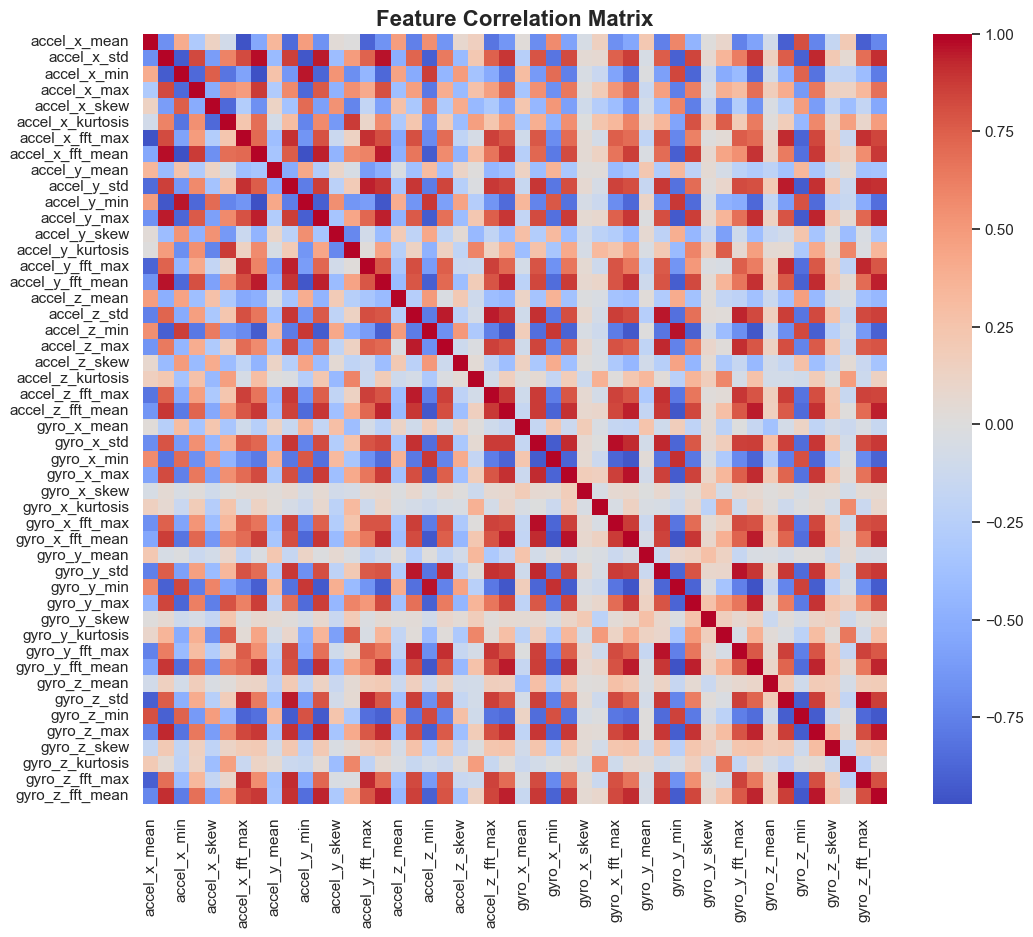

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Create the heatmap ---
plt.figure(figsize=(12, 10))
correlation_matrix = X_binary.corr()
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix", fontsize=16, fontweight="bold")
plt.show()